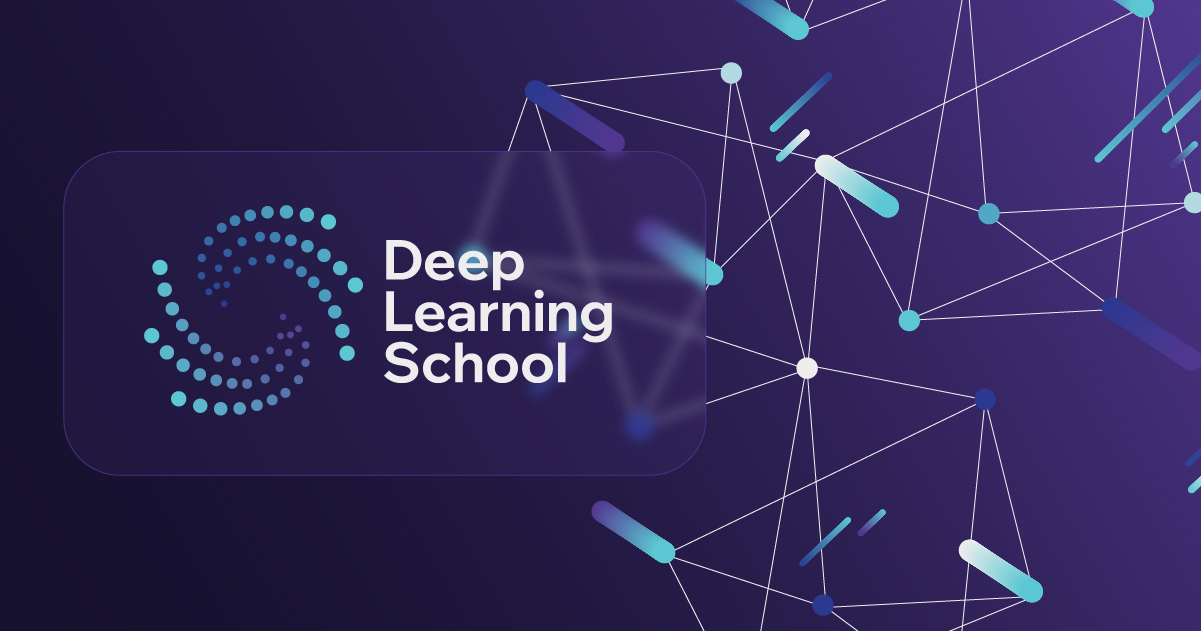


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [4]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [8]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    # Читаем атрибуты
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)

                # Новое, более надёжное парсинг имени файла
                # Пример: "Aaron_Eckhart_0001.jpg" → person="Aaron Eckhart", imagenum=1
                name = fname[:-4]  # убираем .jpg
                parts = name.split('_')
                imagenum = int(parts[-1])
                person = ' '.join(parts[:-1])

                photo_ids.append({
                    'person': person,
                    'imagenum': imagenum,
                    'photo_path': fpath
                })

    photo_ids = pd.DataFrame(photo_ids)

    # Объединяем атрибуты и пути к фото
    df = pd.merge(df_attrs, photo_ids, on=['person', 'imagenum'], how='inner')

    print(f"Загружено изображений: {len(df)}")

    # Загружаем и предобрабатываем изображения
    images = []
    for path in df['photo_path']:
        img = imageio.imread(path)
        img = img[dy:-dy, dx:-dx]                    # обрезаем края
        img = np.array(Image.fromarray(img).resize([dimx, dimy]))
        images.append(img)

    images = np.stack(images).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [9]:
images, attrs = fetch_dataset()
print("Размер изображений:", images.shape)
print("Размер атрибутов:", attrs.shape)

Загружено изображений: 13143


/tmp/ipykernel_1708/3011762832.py:35: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


Размер изображений: (13143, 45, 45, 3)
Размер атрибутов: (13143, 73)



Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

Train size: 10514
Val size:   2629


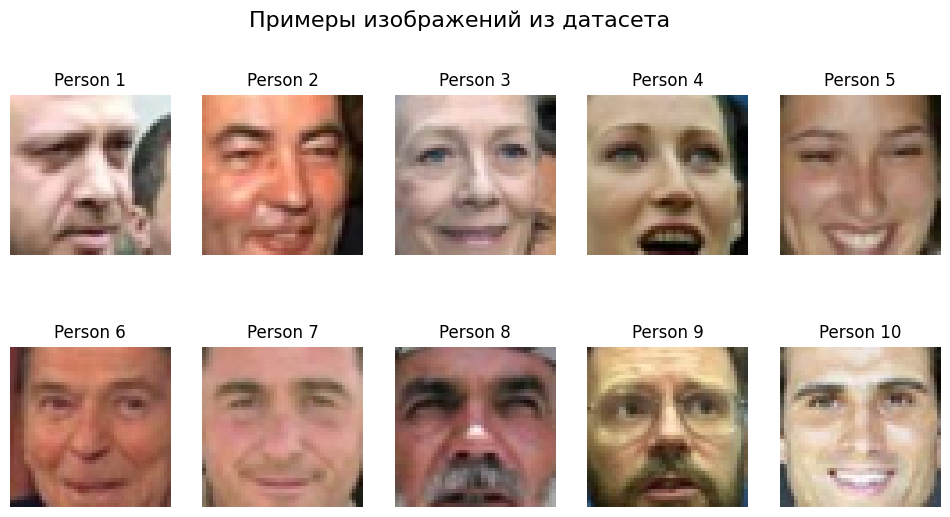

Train tensor shape: torch.Size([10514, 3, 45, 45])
Val tensor shape:   torch.Size([2629, 3, 45, 45])


In [12]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as transforms

train_images, val_images, train_attrs, val_attrs = train_test_split(
    images, attrs, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train size: {train_images.shape[0]}")
print(f"Val size:   {val_images.shape[0]}")

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i])
    plt.title(f"Person {i+1}")
    plt.axis('off')
plt.suptitle("Примеры изображений из датасета", fontsize=16)
plt.show()

# Нормализация: переводим из [0..255] в [0..1] и меняем порядок осей (HWC -> CHW)
def preprocess_images(img_array):
    img_array = img_array.astype('float32') / 255.0
    return torch.tensor(img_array).permute(0, 3, 1, 2)

train_tensors = preprocess_images(train_images)
val_tensors   = preprocess_images(val_images)

print("Train tensor shape:", train_tensors.shape)
print("Val tensor shape:  ", val_tensors.shape)

batch_size = 32

train_dataset = TensorDataset(train_tensors)
val_dataset   = TensorDataset(val_tensors)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



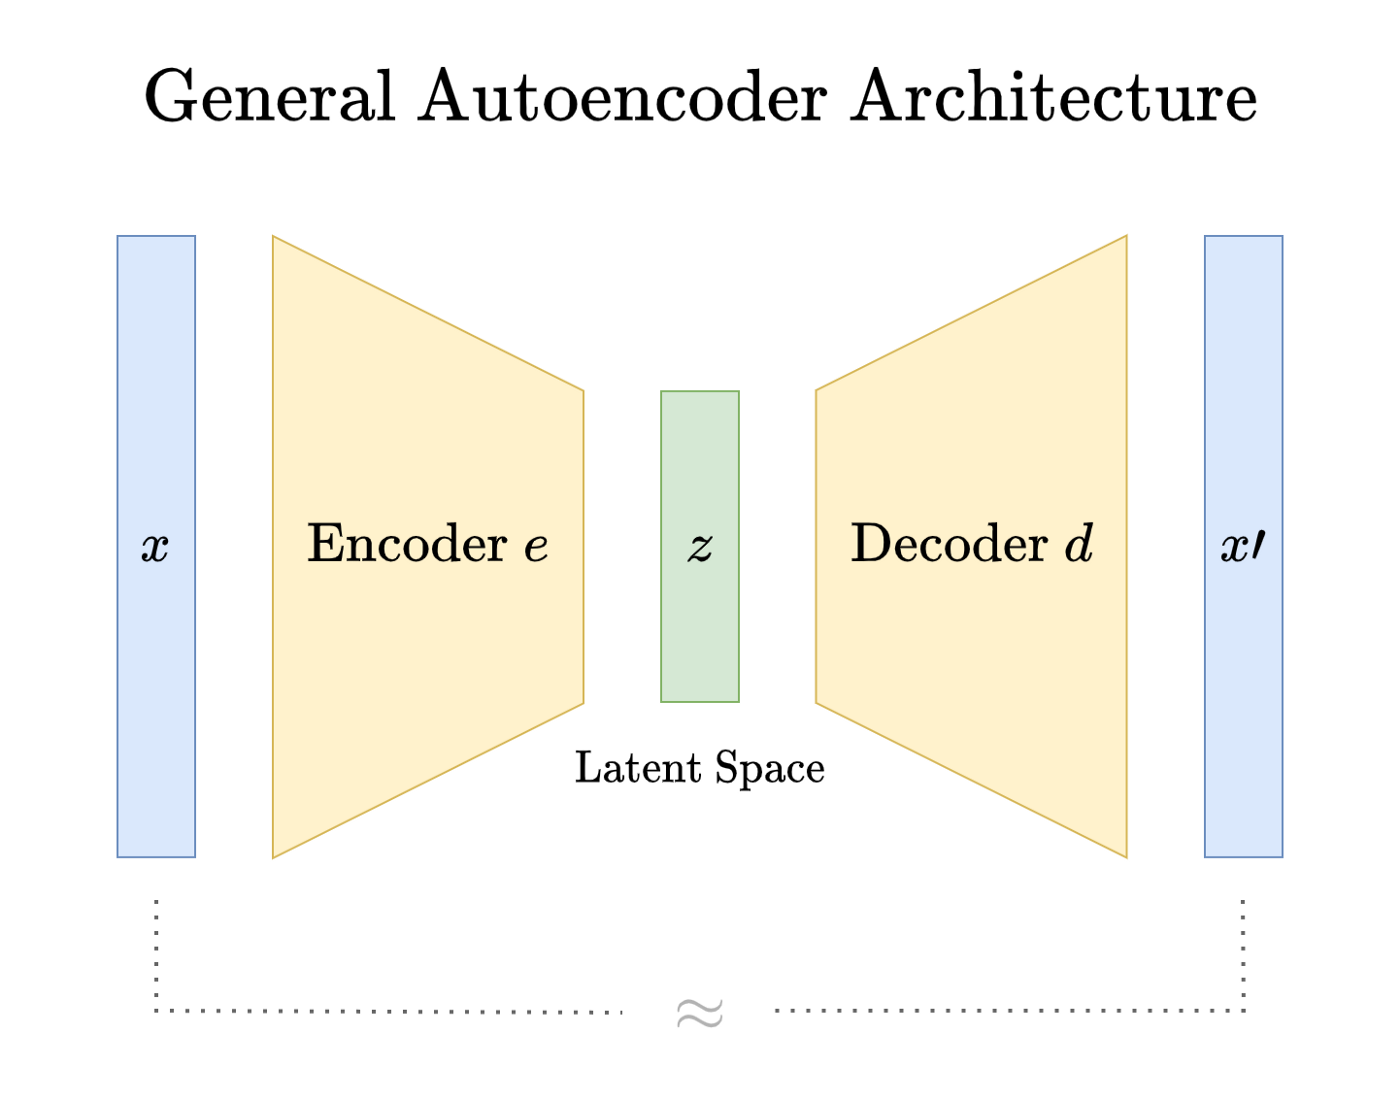

In [13]:
dim_code = 128 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [23]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, dim_code)
        )


        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128 * 6 * 6),
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        if reconstruction.shape[2] != 45:
            reconstruction = reconstruction[:, :, :45, :45]
        return reconstruction, latent_code

In [24]:
criterion = nn.MSELoss()

autoencoder = Autoencoder()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Epoch [7/7] | Train Loss: 0.001958 | Val Loss: 0.002085


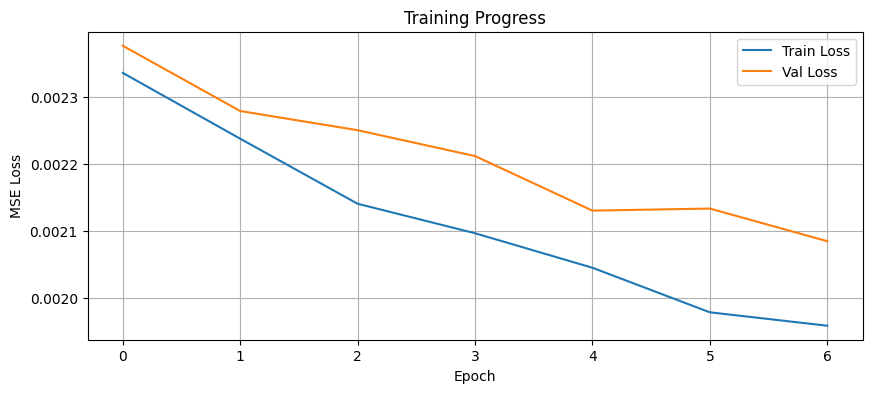

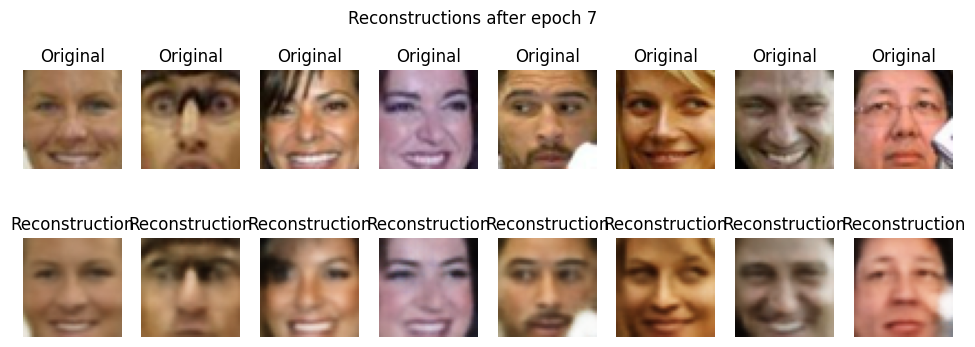

In [26]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

num_epochs = 7
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    autoencoder.train()
    train_loss = 0.0

    for batch in train_loader:
        imgs = batch[0]

        optimizer.zero_grad()
        reconstruction, _ = autoencoder(imgs)
        loss = criterion(reconstruction, imgs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss / len(train_loader))

    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch[0]
            reconstruction, _ = autoencoder(imgs)
            val_loss += criterion(reconstruction, imgs).item()

    val_losses.append(val_loss / len(val_loader))

    clear_output(wait=True)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}")

    # График лоссов
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Показываем реконструкции
    autoencoder.eval()
    with torch.no_grad():
        test_batch = next(iter(val_loader))[0][:8]   # первые 8 картинок
        recon, _ = autoencoder(test_batch)

        plt.figure(figsize=(12, 4))
        for i in range(8):
            # Оригинал
            plt.subplot(2, 8, i+1)
            plt.imshow(test_batch[i].permute(1, 2, 0))
            plt.axis('off')
            plt.title('Original')

            # Реконструкция
            plt.subplot(2, 8, i+9)
            plt.imshow(recon[i].permute(1, 2, 0))
            plt.axis('off')
            plt.title('Reconstruction')
        plt.suptitle(f'Reconstructions after epoch {epoch+1}')
        plt.show()

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

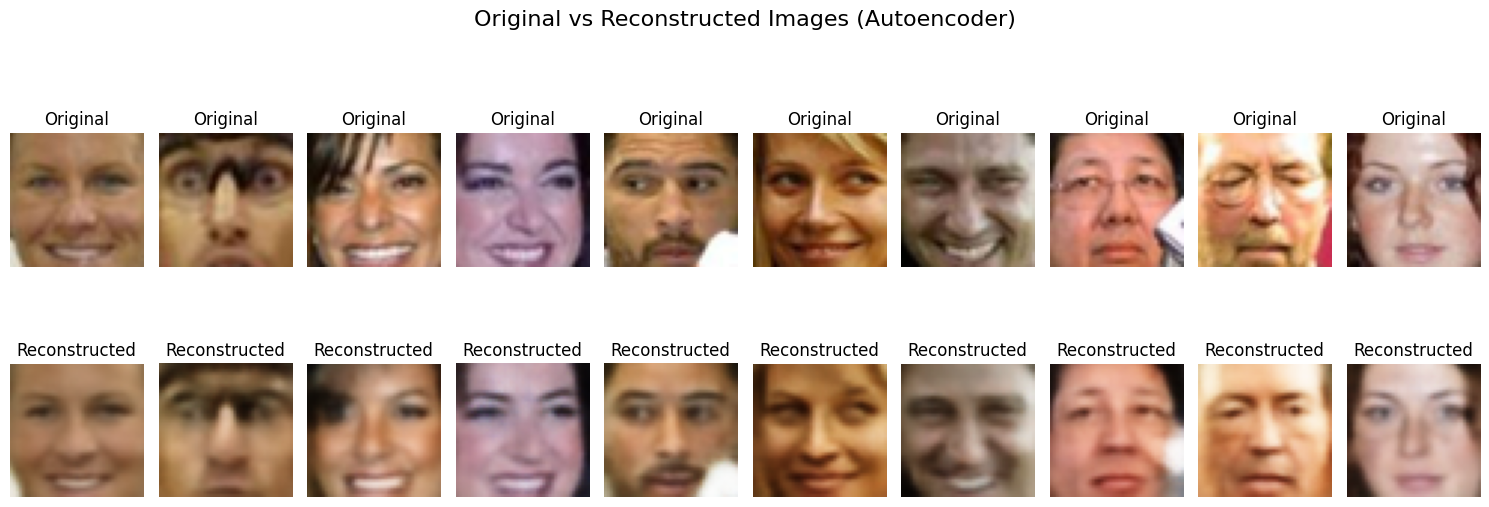

In [27]:
autoencoder.eval()

with torch.no_grad():
    val_batch = next(iter(val_loader))[0][:10]
    reconstructions, latent_codes = autoencoder(val_batch)

# Визуализация
plt.figure(figsize=(15, 6))
for i in range(10):
    # Оригинальное изображение
    plt.subplot(2, 10, i + 1)
    plt.imshow(val_batch[i].permute(1, 2, 0))
    plt.axis('off')
    plt.title('Original')

    # Реконструкция
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].permute(1, 2, 0))
    plt.axis('off')
    plt.title('Reconstructed')

plt.suptitle('Original vs Reconstructed Images (Autoencoder)', fontsize=16)
plt.tight_layout()
plt.show()

Что вы можете сказать про результат?

Автоэнкодер достаточно хорошо восстанавливает общую форму лица, расположение глаз, носа и рта, цвет кожи. Однако реконструкции получаются заметно размытыми. теряются мелкие детали, текстура кожи, морщины и чёткость глаз.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

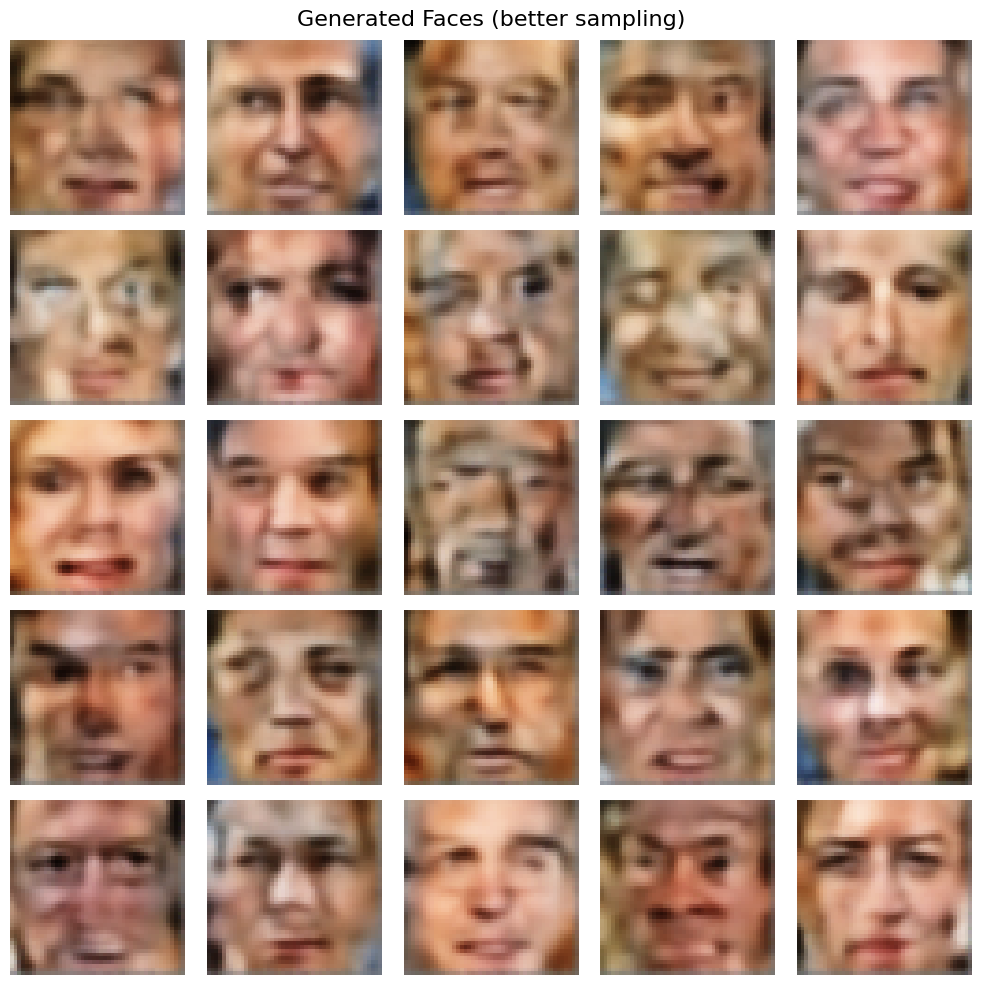

In [30]:
autoencoder.eval()
with torch.no_grad():
    # Получаем латентные векторы из val выборки
    all_latents = []
    for batch in val_loader:
        imgs = batch[0]
        _, latent = autoencoder(imgs)
        all_latents.append(latent)

    all_latents = torch.cat(all_latents, dim=0)

    latent_mean = all_latents.mean(dim=0)
    latent_std = all_latents.std(dim=0)

# Генерируем новые векторы с похожим распределением
z = latent_mean + latent_std * torch.randn(25, dim_code)

with torch.no_grad():
    generated_images = autoencoder.decoder(z)

# Визуализация
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_images[i].permute(1, 2, 0).clamp(0,1))
    plt.axis('off')
plt.suptitle('Generated Faces (better sampling)', fontsize=16)
plt.tight_layout()
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

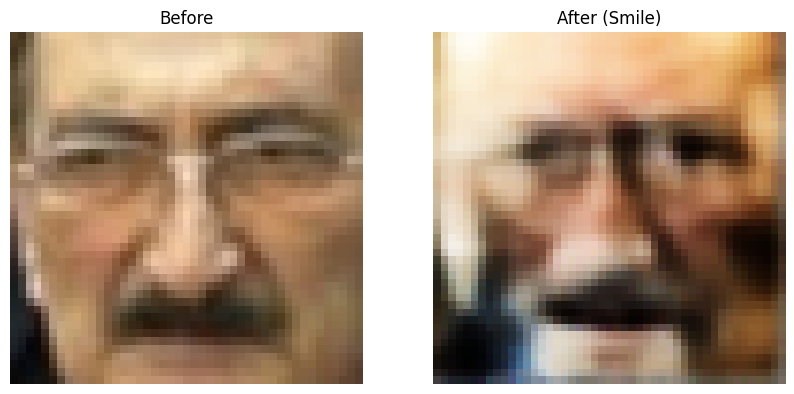

In [39]:
autoencoder.eval()

smile_idx = np.where(attrs['Smiling'] > 0.7)[0]
no_smile_idx = np.where(attrs['Smiling'] < -0.5)[0]

smile_images = torch.stack([train_tensors[i] for i in smile_idx[:40]])
no_smile_images = torch.stack([train_tensors[i] for i in no_smile_idx[:40]])

with torch.no_grad():
    smile_latents = autoencoder.encoder(smile_images)
    no_smile_latents = autoencoder.encoder(no_smile_images)

smile_vector = smile_latents.mean(dim=0) - no_smile_latents.mean(dim=0)

sad_idx = no_smile_idx[66]

sad_person = train_tensors[sad_idx].unsqueeze(0)

with torch.no_grad():
    sad_latent = autoencoder.encoder(sad_person)
    happy_latent = sad_latent + 7.0 * smile_vector
    happy_person = autoencoder.decoder(happy_latent)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sad_person[0].permute(1, 2, 0))
plt.title("Before")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(happy_person[0].permute(1, 2, 0))
plt.title("After (Smile)")
plt.axis('off')
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [42]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 139MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 52.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 61.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.93MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [43]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, dim_code)
        self.fc_logsigma = nn.Linear(64 * 7 * 7, dim_code)

        # Decoder
        self.decoder_fc = nn.Linear(dim_code, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        z = self.decoder_fc(z)
        return self.decoder(z)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [44]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp(), dim=1)
    return loss.mean()

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    loss = nn.functional.binary_cross_entropy(reconstruction, x, reduction='none')
    return loss.sum(dim=(1, 2, 3)).mean()

def loss_vae(x, mu, logsigma, reconstruction):
    """
    Общий лосс VAE
    """
    return log_likelihood(x, reconstruction) + KL_divergence(mu, logsigma)

И обучим модель:

In [45]:
dim_code = 64

criterion = loss_vae

vae = VAE()
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

Epoch [7/7] | Train Loss: 103.7929 | Val Loss: 92.1956


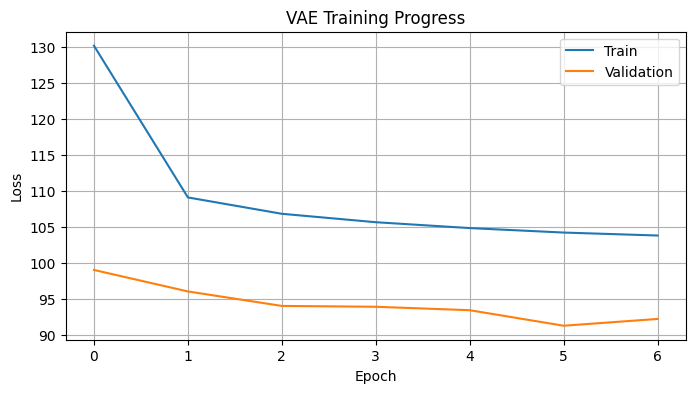

In [46]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

num_epochs = 7
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    vae.train()
    train_loss = 0.0
    for batch, _ in train_loader:
        imgs = batch.to(device) if torch.cuda.is_available() else batch

        optimizer.zero_grad()
        mu, logsigma, reconstruction = vae(imgs)
        loss = criterion(imgs, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss / len(train_loader))

    # Validation
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch, _ in test_loader:
            imgs = batch.to(device) if torch.cuda.is_available() else batch
            mu, logsigma, reconstruction = vae(imgs)
            loss = criterion(imgs, mu, logsigma, reconstruction)
            val_loss += loss.item()

    val_losses.append(val_loss / len(test_loader))

    # Вывод
    clear_output(wait=True)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

    plt.figure(figsize=(8,4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('VAE Training Progress')
    plt.grid(True)
    plt.show()

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

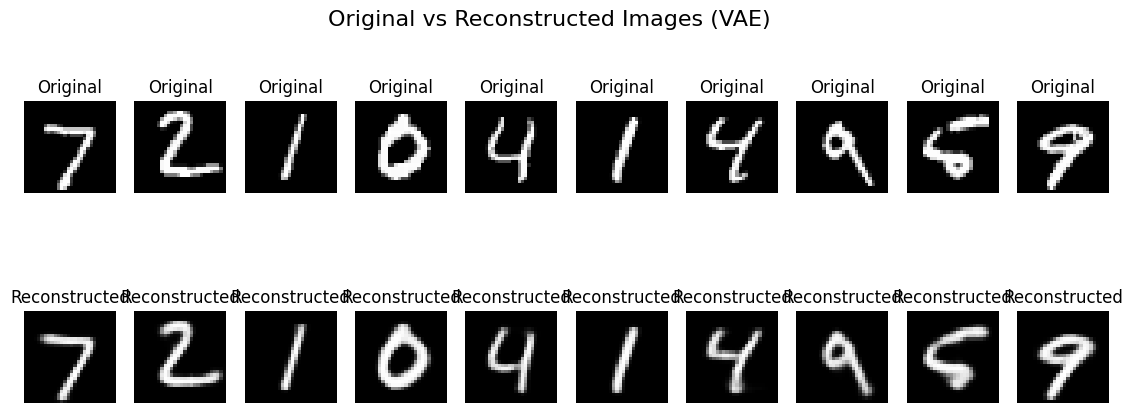

In [47]:
vae.eval()

with torch.no_grad():
    # Берем первые 10 картинок из test_loader
    test_batch = next(iter(test_loader))[0][:10]
    mu, logsigma, reconstructions = vae(test_batch)

plt.figure(figsize=(14, 5))
for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(test_batch[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Original')

    # Реконструкция
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Reconstructed')

plt.suptitle('Original vs Reconstructed Images (VAE)', fontsize=16)
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

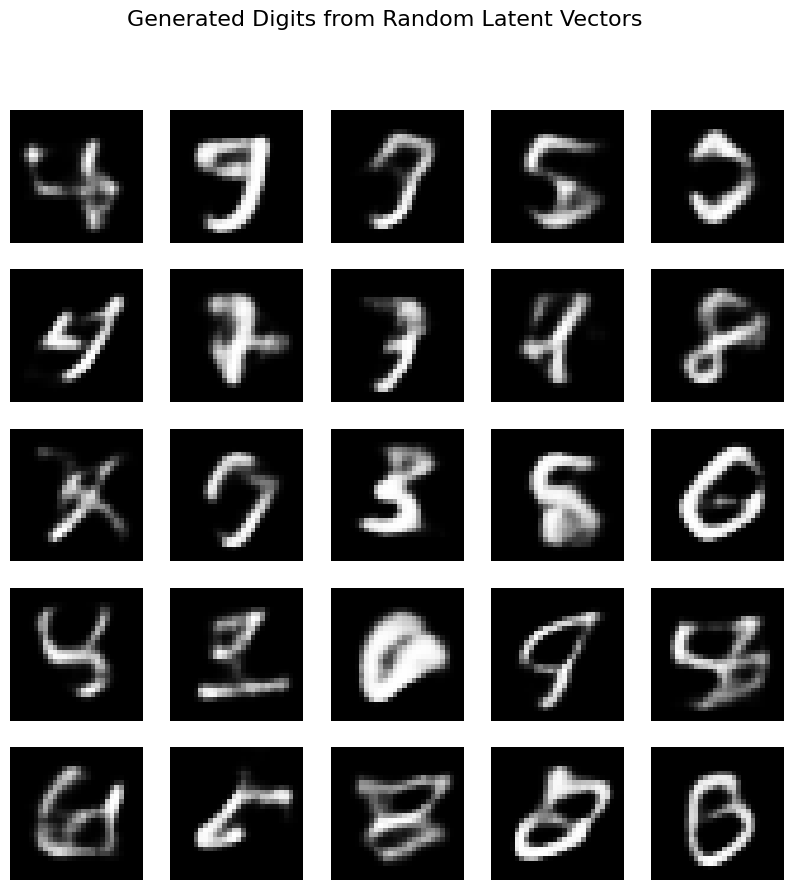

In [48]:
vae.eval()

# Генерируем 25 случайных векторов
z = torch.randn(25, dim_code)

with torch.no_grad():
    generated = vae.decode(z)

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Digits from Random Latent Vectors', fontsize=16)
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

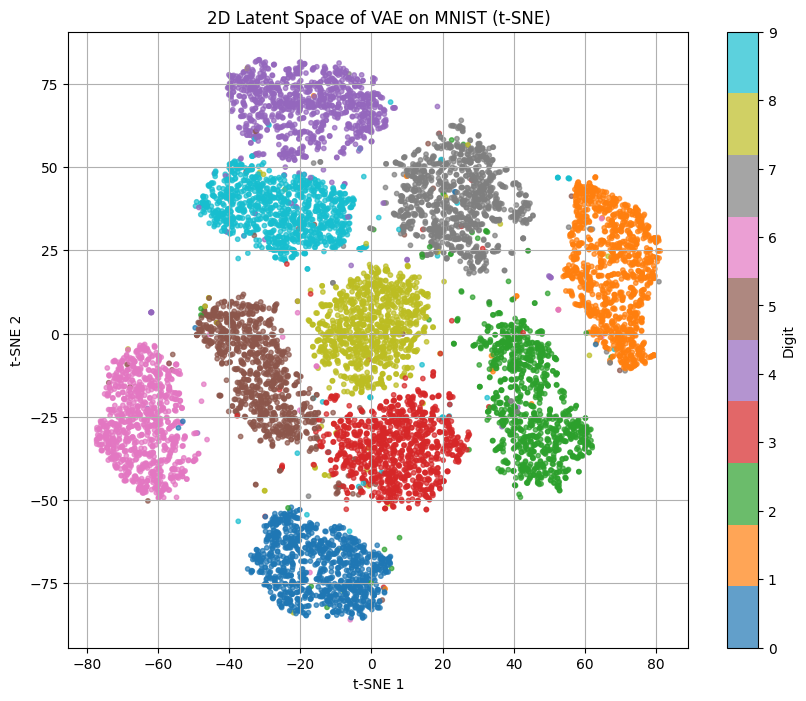

In [49]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

vae.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for batch, label in test_loader:
        mu, _ = vae.encode(batch)
        latent_vectors.append(mu)
        labels.append(label)

latent_vectors = torch.cat(latent_vectors, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', alpha=0.7, s=10)

plt.colorbar(scatter, label='Digit')
plt.title('2D Latent Space of VAE on MNIST (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

Что вы думаете о виде латентного представления?

Латентное пространство получилось хорошо организованным. Разные цифры образуют отдельные, достаточно компактные кластеры, которые почти не пересекаются.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [61]:
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.latent_dim = 64

        # Encoder — только 2 conv-слоя, как в рабочем VAE выше
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # → 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # → 7x7
            nn.ReLU(),
            nn.Flatten()   # → 64*7*7 = 3136
        )

        # После Flatten: 3136 + 10 (one-hot)
        self.fc_mu       = nn.Linear(64 * 7 * 7 + 10, self.latent_dim)
        self.fc_logsigma = nn.Linear(64 * 7 * 7 + 10, self.latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(self.latent_dim + 10, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # → 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1,  kernel_size=4, stride=2, padding=1),  # → 28x28
            nn.Sigmoid()
        )

    def encode(self, x, class_num):
        class_onehot = F.one_hot(class_num, 10).float().to(x.device)
        x = self.encoder(x)                          # (B, 3136)
        x = torch.cat([x, class_onehot], dim=1)      # (B, 3146)
        return self.fc_mu(x), self.fc_logsigma(x)

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, class_num):
        class_onehot = F.one_hot(class_num, 10).float().to(z.device)
        z = torch.cat([z, class_onehot], dim=1)      # (B, 74)
        z = self.decoder_input(z)                    # (B, 3136)
        return self.decoder(z)

    def forward(self, x, class_num):
        mu, logsigma = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z, class_num)
        return mu, logsigma, recon

In [62]:
dim_code = cvae.latent_dim
latent = torch.randn(1, dim_code).to(device)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Epoch 1/10, Loss = 126.5576
Epoch 2/10, Loss = 105.9729
Epoch 3/10, Loss = 103.6203
Epoch 4/10, Loss = 102.2526
Epoch 5/10, Loss = 101.3174
Epoch 6/10, Loss = 100.5781
Epoch 7/10, Loss = 100.0174
Epoch 8/10, Loss = 99.5133
Epoch 9/10, Loss = 99.1028
Epoch 10/10, Loss = 98.7121


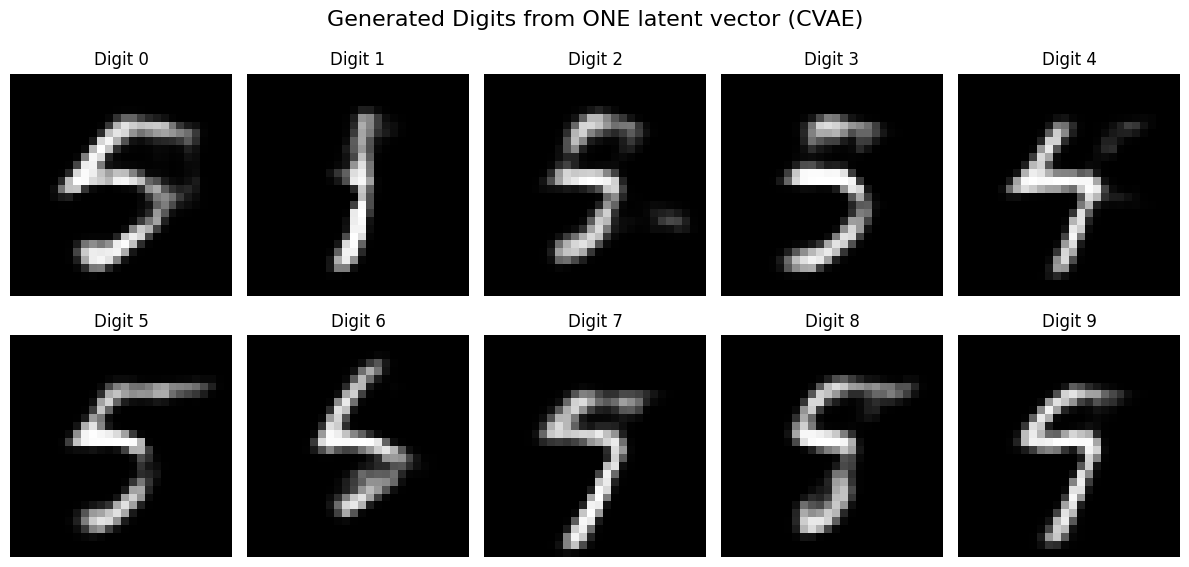

In [65]:

cvae = CVAE().to(device)
optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)

num_epochs = 10
for epoch in range(num_epochs):
    cvae.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        mu, logsigma, recon = cvae(images, labels)
        loss = loss_vae(images, mu, logsigma, recon)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss = {total_loss/len(train_loader):.4f}")

cvae.eval()
dim_code = cvae.latent_dim
latent = torch.randn(1, dim_code).to(device)

plt.figure(figsize=(12, 6))
for digit in range(10):
    class_num = torch.tensor([digit]).to(device)
    with torch.no_grad():
        generated = cvae.decode(latent, class_num)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(generated[0].squeeze().cpu().numpy(), cmap='gray')
    plt.title(f'Digit {digit}')
    plt.axis('off')

plt.suptitle('Generated Digits from ONE latent vector (CVAE)', fontsize=16)
plt.tight_layout()
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

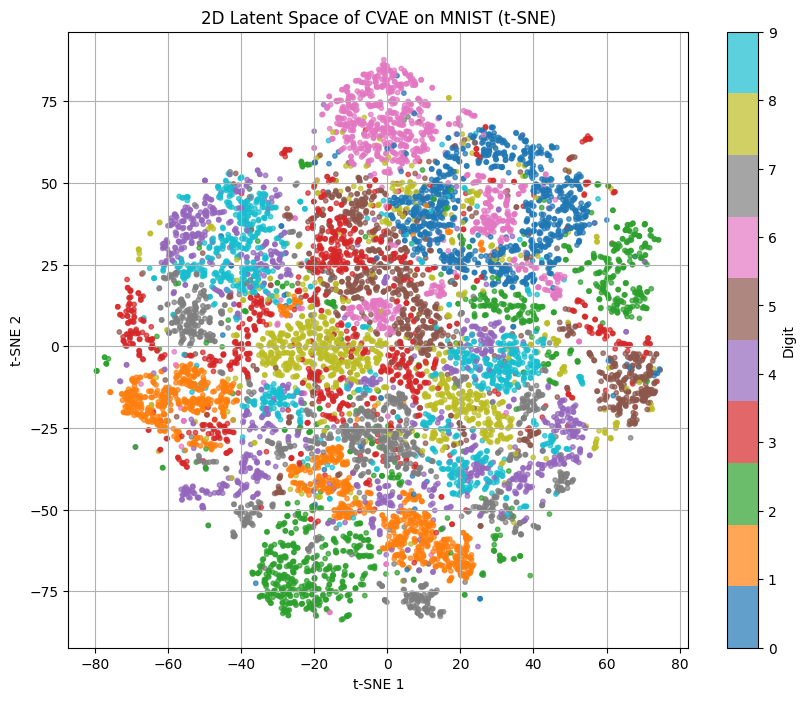

In [66]:
cvae.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for batch, label in test_loader:
        batch = batch.to(device)
        label = label.to(device)
        mu, _ = cvae.encode(batch, label)
        latent_vectors.append(mu.cpu())
        labels.append(label.cpu())

latent_vectors = torch.cat(latent_vectors, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, label='Digit')
plt.title('2D Latent Space of CVAE on MNIST (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Латентное пространство CVAE выглядит более размытым и перемешанным по сравнению с VAE

Бонус не выполнен

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудьте разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает шум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>